# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

In [2]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [3]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

import matplotlib.pyplot as plt

Text(0, 0.5, 'Loss function')

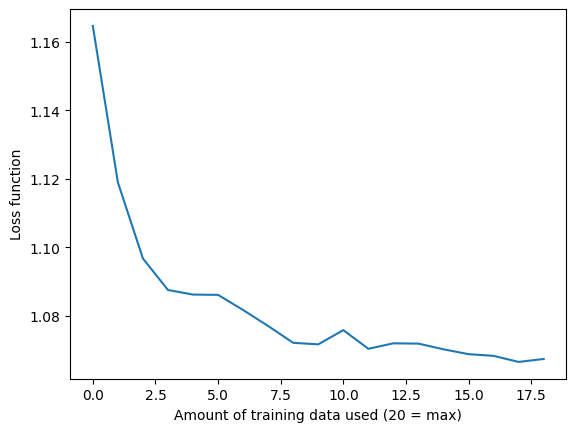

In [4]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [5]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

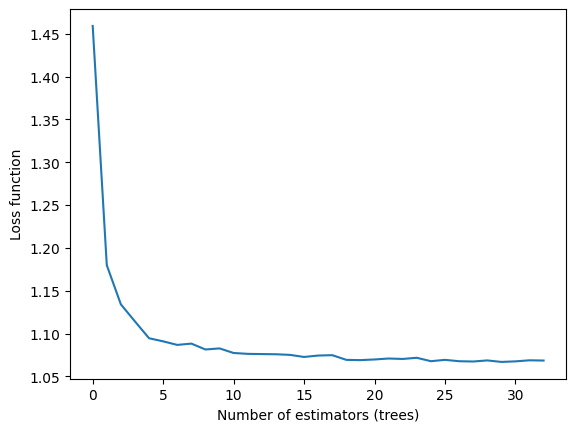

In [6]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

In [11]:
df = pd.read_csv("/workspaces/Module-B-semester-2/credit_risk_dataset.csv")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [13]:
df_clean=df.dropna()
df_clean.info()

<class 'pandas.DataFrame'>
Index: 28638 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  28638 non-null  int64  
 1   person_income               28638 non-null  int64  
 2   person_home_ownership       28638 non-null  str    
 3   person_emp_length           28638 non-null  float64
 4   loan_intent                 28638 non-null  str    
 5   loan_grade                  28638 non-null  str    
 6   loan_amnt                   28638 non-null  int64  
 7   loan_int_rate               28638 non-null  float64
 8   loan_status                 28638 non-null  int64  
 9   loan_percent_income         28638 non-null  float64
 10  cb_person_default_on_file   28638 non-null  str    
 11  cb_person_cred_hist_length  28638 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 2.8 MB


In [16]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

X = df_clean.drop(columns=['loan_status'])
y = df_clean['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, stratify=y, random_state=42
)

categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = X.select_dtypes(include=['number']).columns.tolist()

/tmp/ipykernel_58310/1971356463.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()


In [20]:
preprocessor = ColumnTransformer(
transformers=[
('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
],
remainder='passthrough'
)


rf = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42, n_jobs=-1)
pipeline = Pipeline([
('preproc', preprocessor),
('clf', rf)
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1] if hasattr(pipeline.named_steps['clf'], "predict_proba") else None

print(classification_report(y_test, y_pred))
print('Confusion matrix:')
print(confusion_matrix(y_test, y_pred))
if y_proba is not None:
    print('ROC AUC:', roc_auc_score(y_test, y_proba))

param_grid = { 'clf__n_estimators': [100, 200], 'clf__max_depth': [None, 10, 20], 'clf__max_features': ['sqrt', 0.5], 'clf__min_samples_split': [2, 5] }
grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)
print('Best params:', grid.best_params_)
best_model = grid.best_estimator_

              precision    recall  f1-score   support

           0       0.92      0.99      0.96      4487
           1       0.97      0.70      0.81      1241

    accuracy                           0.93      5728
   macro avg       0.94      0.85      0.89      5728
weighted avg       0.93      0.93      0.93      5728

Confusion matrix:
[[4456   31]
 [ 369  872]]
ROC AUC: 0.9264734167126556
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best params: {'clf__max_depth': None, 'clf__max_features': 0.5, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}


In [21]:
y_pred_best = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred_best))
print('ROC AUC:', roc_auc_score(y_test, y_proba_best))

              precision    recall  f1-score   support

           0       0.93      0.99      0.96      4487
           1       0.97      0.71      0.82      1241

    accuracy                           0.93      5728
   macro avg       0.95      0.85      0.89      5728
weighted avg       0.93      0.93      0.93      5728

ROC AUC: 0.9313057131471398


In [22]:
ohe = grid.best_estimator_.named_steps['preproc'].named_transformers_['cat'] if 'cat' in grid.best_estimator_.named_steps['preproc'].named_transformers_ else None

In [29]:
pre = pipeline.named_steps['preproc']
clf = pipeline.named_steps['clf']

cat_features = []
if hasattr(pre.named_transformers_['cat'], 'get_feature_names_out'):
    cat_features = pre.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist()
else:
    cat_features = pre.named_transformers_['cat'].get_feature_names(categorical_cols).tolist()
feature_names = cat_features + numeric_cols
importances = clf.feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
print(feat_imp.head(20))

loan_percent_income               0.222946
person_income                     0.136073
loan_int_rate                     0.126825
loan_amnt                         0.072225
person_emp_length                 0.061652
person_home_ownership_RENT        0.056082
loan_grade_D                      0.049887
person_age                        0.045092
cb_person_cred_hist_length        0.034035
person_home_ownership_MORTGAGE    0.025034
loan_intent_DEBTCONSOLIDATION     0.024137
loan_intent_MEDICAL               0.021722
loan_grade_C                      0.020732
person_home_ownership_OWN         0.017250
loan_intent_HOMEIMPROVEMENT       0.014076
loan_grade_E                      0.012970
loan_intent_EDUCATION             0.010602
loan_intent_PERSONAL              0.008295
loan_intent_VENTURE               0.007957
loan_grade_A                      0.007832
dtype: float64


**Notes for discussing in milestone:** <br>
As expected during preliminary analysis, the most important factor given in our random forest model is loan percent of income variable. Person income and loan interes rates were runner ups in terms of importance. 

# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

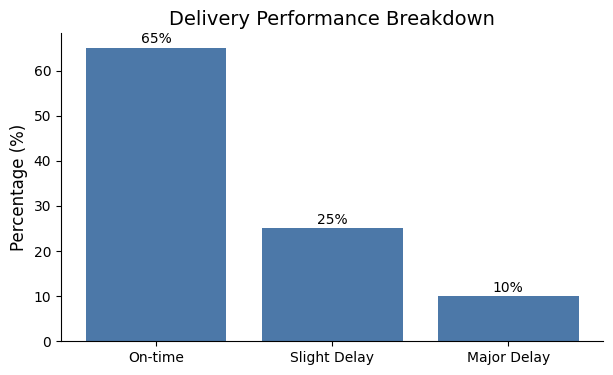

In [7]:
import matplotlib.pyplot as plt

categories = ["On-time", "Slight Delay", "Major Delay"]
values = [65, 25, 10]

plt.figure(figsize=(7,4))

plt.bar(categories, values, color="#4C78A8")

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.title("Delivery Performance Breakdown", fontsize=14)
plt.ylabel("Percentage (%)", fontsize=12)

for i, v in enumerate(values):
    plt.text(i, v + 1, str(v) + "%", ha="center", fontsize=10)

plt.show()